<a href="https://colab.research.google.com/github/Quy20061/Hoc_May/blob/main/Tuan3_Bai1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


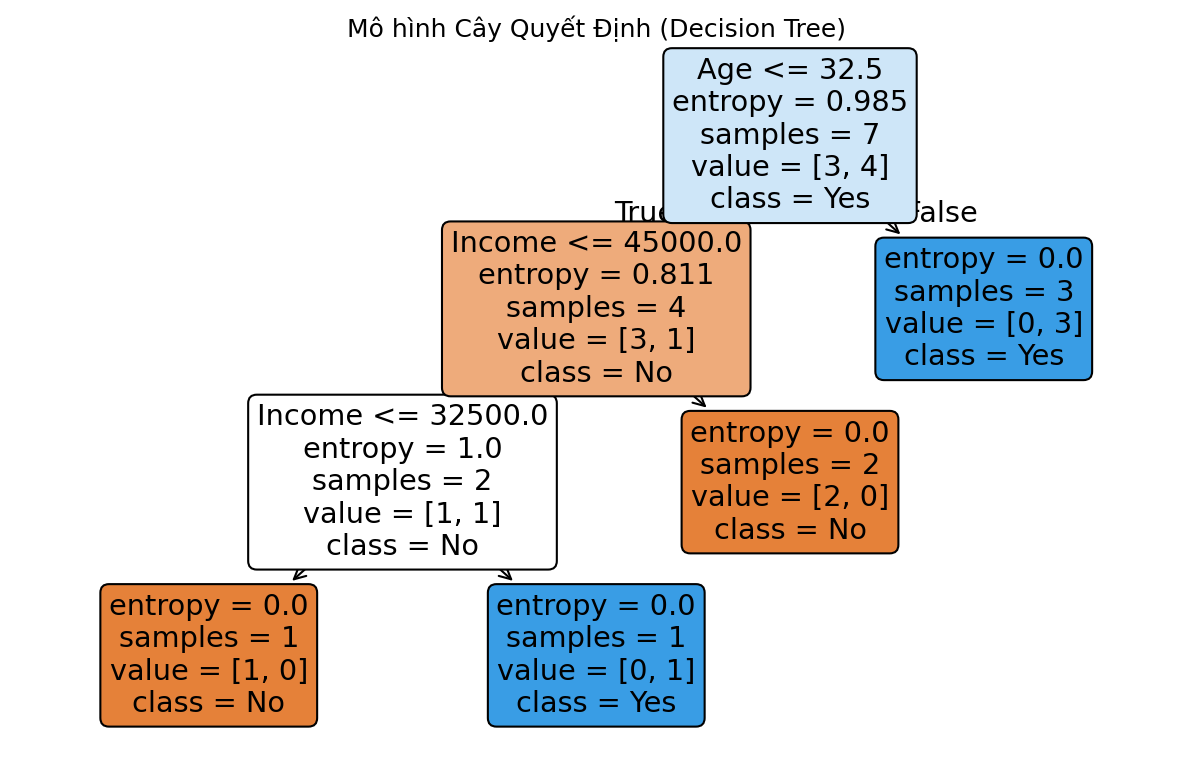

-> Dự đoán bằng Cây Quyết Định (Age=32, Income=58000): No
-> Dự đoán bằng KNN (k=3) (Age=32, Income=58000): No


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Đường dẫn chính xác tới file trong thư mục "Học máy"
file_path = '/content/drive/MyDrive/Học máy/DL1.csv'
df = pd.read_csv(file_path)

# 2. Xử lý cột Income
df['Income_Clean'] = df['Income ($)'].astype(str).str.replace(',', '').str.replace('$', '').str.strip().astype(float)
X = df[['Age', 'Income_Clean']]
y = df['Purchased']

# Mẫu cần dự đoán: Age = 32, Income = 58,000
sample = pd.DataFrame([[32, 58000]], columns=['Age', 'Income_Clean'])

# ==========================================
# 1. CÂY QUYẾT ĐỊNH (DECISION TREE) - VẼ HÌNH CÂY
# ==========================================
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X, y)

plt.figure(figsize=(10, 6), dpi=150)
plot_tree(dt, feature_names=['Age', 'Income'], class_names=dt.classes_, filled=True, rounded=True)
plt.title("Mô hình Cây Quyết Định (Decision Tree)")
plt.show()

pred_dt = dt.predict(sample)
print(f"-> Dự đoán bằng Cây Quyết Định (Age=32, Income=58000): {pred_dt[0]}")

# ==========================================
# 2. KNN (k=3)
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
sample_scaled = scaler.transform(sample)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

pred_knn = knn.predict(sample_scaled)
print(f"-> Dự đoán bằng KNN (k=3) (Age=32, Income=58000): {pred_knn[0]}")